# WORK IN PROGRESS

# Final Project

#### Title: Machine Learning for Obesity Level Prediction and Lifesytle Pattern Discovery
#### Class: AAI 501-02 - Introduction to Artificial Intelligence
#### Team 4: Dina Othman, Erika Gallegos, Hassaan Abbasi

In [13]:
## libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from scipy.sparse import hstack
from xgboost import plot_tree

import os
import seaborn as sns
%matplotlib inline
sns.set(style="whitegrid", context="notebook")

## Data

In [3]:
# Import data from Github

url = 'https://raw.githubusercontent.com/hassaanabbasi98/ProjectAAI-501-ObseityLevel-/main/ObesityDataSet_raw_and_data_sinthetic.csv'

df = pd.read_csv(url)
df.head()


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


## Data Cleaning

In [4]:
#  basic cleaning

# 1) Drop exact duplicate rows
df_clean = df.drop_duplicates().reset_index(drop=True)
print("Shape after dropping duplicates:", df_clean.shape)

# 2) No missing values in this dataset,
missing_counts = df_clean.isna().sum()
print("Missing values per column after cleaning:")
print(missing_counts)

# 3) Verify dtypes
print("\nData types:")
print(df_clean.dtypes)


Shape after dropping duplicates: (2087, 17)
Missing values per column after cleaning:
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

Data types:
Gender                             object
Age                               float64
Height                            float64
Weight                            float64
family_history_with_overweight     object
FAVC                               object
FCVC                    

## EDA

Distributions, correlations, key lifestyle variables.
Keeping the EDA on unencoded data so plots are interpretable.

In [4]:
#  column groups

target_col = "NObeyesdad"

categorical_cols = ["Gender","family_history_with_overweight","FAVC","CAEC","SMOKE","SCC","CALC","MTRANS",
    target_col,  # keep target in its own group when needed
]

numeric_cols = ["Age","Height","Weight","FCVC", "NCP","CH2O","FAF", "TUE",]

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)


Numeric columns: ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
Categorical columns: ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS', 'NObeyesdad']


Summary of Statisitcs After cleaning and EDA-Distruibution

In [5]:
print("Numeric summary:")
display(df_clean[numeric_cols].describe())

print("\nCategorical summary (value counts):")
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df_clean[col].value_counts())

Numeric summary:


,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000
mean,24.353090,1.702674,86.858730,2.421466,2.701179,2.004749,1.012812,0.663035
std,6.368801,0.093186,26.190847,0.534737,0.764614,0.608284,0.853475,0.608153
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.915937,1.630178,66.000000,2.000000,2.697467,1.590922,0.124505,0.000000
50%,22.847618,1.701584,83.101100,2.396265,3.000000,2.000000,1.000000,0.630866
75%,26.000000,1.769491,108.015907,3.000000,3.000000,2.466193,1.678102,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000



Categorical summary (value counts):

--- Gender ---
Gender
Male      1052
Female    1035
Name: count, dtype: int64

--- family_history_with_overweight ---
family_history_with_overweight
yes    1722
no      365
Name: count, dtype: int64

--- FAVC ---
FAVC
yes    1844
no      243
Name: count, dtype: int64

--- CAEC ---
CAEC
Sometimes     1761
Frequently     236
Always          53
no              37
Name: count, dtype: int64

--- SMOKE ---
SMOKE
no     2043
yes      44
Name: count, dtype: int64

--- SCC ---
SCC
no     1991
yes      96
Name: count, dtype: int64

--- CALC ---
CALC
Sometimes     1380
no             636
Frequently      70
Always           1
Name: count, dtype: int64

--- MTRANS ---
MTRANS
Public_Transportation    1558
Automobile                456
Walking                    55
Motorbike                  11
Bike                        7
Name: count, dtype: int64

--- NObeyesdad ---
NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Ove

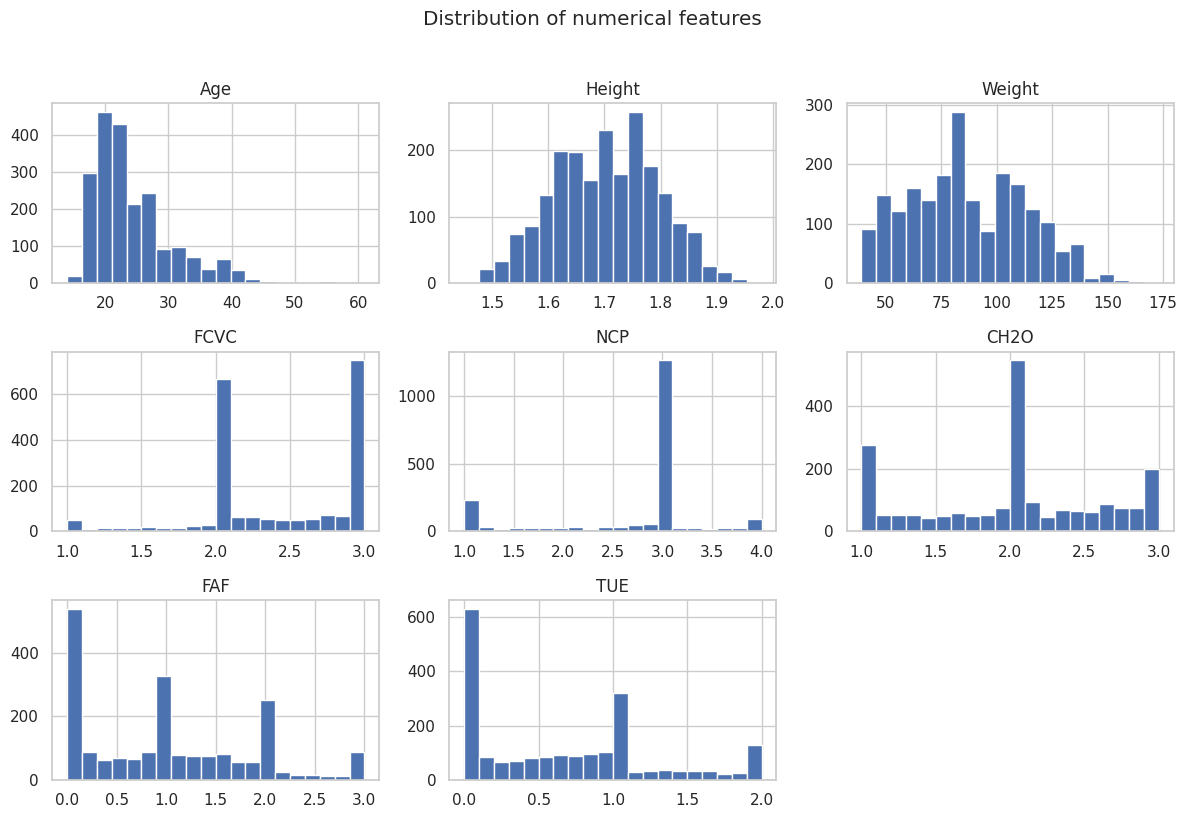

In [6]:
# histograms for numeric features
df_clean[numeric_cols].hist(bins=20, figsize=(12, 8))
plt.suptitle("Distribution of numerical features", y=1.02)
plt.tight_layout()
plt.show()


Targer Distribution

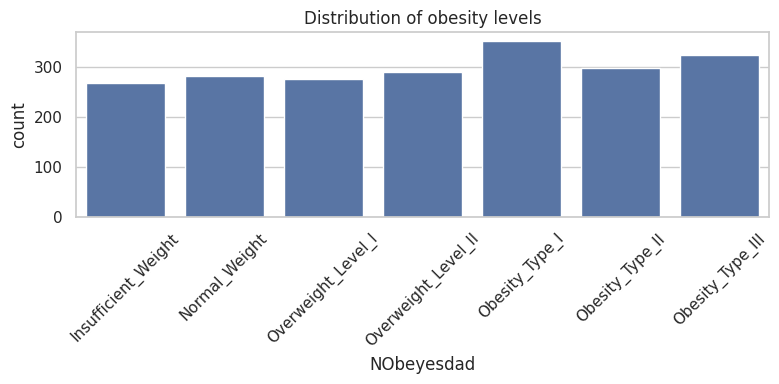

In [7]:
# target distribution

obesity_order = ["Insufficient_Weight","Normal_Weight", "Overweight_Level_I","Overweight_Level_II","Obesity_Type_I","Obesity_Type_II","Obesity_Type_III",]

plt.figure(figsize=(8, 4))
sns.countplot(
    data=df_clean,
    x=target_col,
    order=obesity_order,
)
plt.xticks(rotation=45)
plt.title("Distribution of obesity levels")
plt.tight_layout()
plt.show()


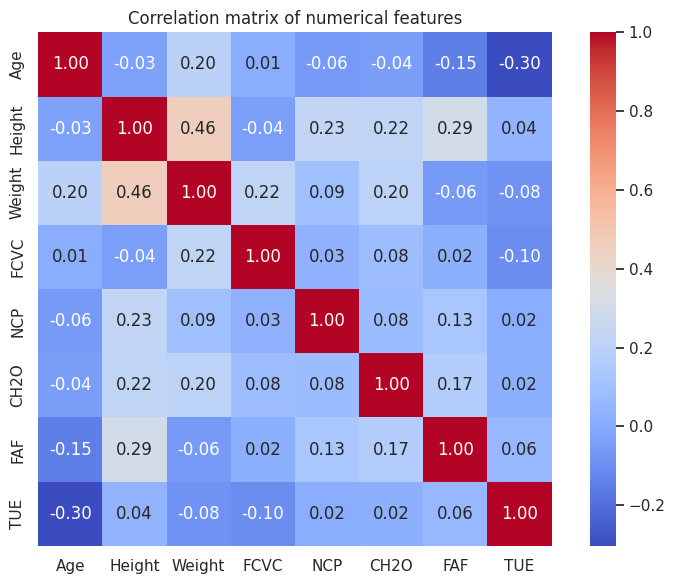

In [8]:
# correlation matrix

corr = df_clean[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation matrix of numerical features")
plt.tight_layout()
plt.show()


## Supervised Machine Learning

Predicting obesity level (NObeyesdad).

### Logistic Regression



#### Preprocessing

In [61]:
## data preparation per logistic regression formatting

# split features (x) and target (y)
X = df_clean.drop('NObeyesdad', axis = 1)
y = df_clean['NObeyesdad']

# get column types
categorical_cols = X.select_dtypes(include = ['object', 'category']).columns.tolist()
numeric_cols = X.select_dtypes(include = ['int64', 'float64']).columns.tolist()

# split 80% (train) / 20% (test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 33, stratify = y)

# one-hot encode categoricals
ohe_lr = OneHotEncoder(drop = 'first', handle_unknown = 'ignore', sparse_output = False)

# scale numerics
scaler_lr = StandardScaler()

# fit on training data
X_train_cat = ohe_lr.fit_transform(X_train[categorical_cols])
X_test_cat = ohe_lr.transform(X_test[categorical_cols])

X_train_num = scaler_lr.fit_transform(X_train[numeric_cols])
X_test_num = scaler_lr.transform(X_test[numeric_cols])

# combine numeric + categorical
X_train_lr = np.hstack([X_train_num, X_train_cat])
X_test_lr = np.hstack([X_test_num, X_test_cat])

# build feature names
encoded_cat_names = ohe_lr.get_feature_names_out(categorical_cols)
lr_feature_names = numeric_cols + list(encoded_cat_names)

#### Model

In [65]:
## train model
lr_model = LogisticRegression()

lr_model.fit(X_train_lr, y_train)

LogisticRegression()

In [70]:
## evaluate model performance on test data
y_pred_lr = lr_model.predict(X_test_lr)
accuracy_lr = accuracy_score(y_test, y_pred_lr)

class_names = sorted(y.unique())

print('Logistic Regression Performance:')
print(f'Accuracy = {accuracy_lr:.4f}')
print('Classification Report:')
print(classification_report(y_test, y_pred_lr, target_names = class_names))

Logistic Regression Performance:
Accuracy = 0.8971
Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.87      1.00      0.93        53
      Normal_Weight       0.93      0.74      0.82        57
     Obesity_Type_I       0.98      0.89      0.93        70
    Obesity_Type_II       0.95      1.00      0.98        60
   Obesity_Type_III       0.98      1.00      0.99        65
 Overweight_Level_I       0.76      0.80      0.78        55
Overweight_Level_II       0.79      0.84      0.82        58

           accuracy                           0.90       418
          macro avg       0.90      0.90      0.89       418
       weighted avg       0.90      0.90      0.90       418



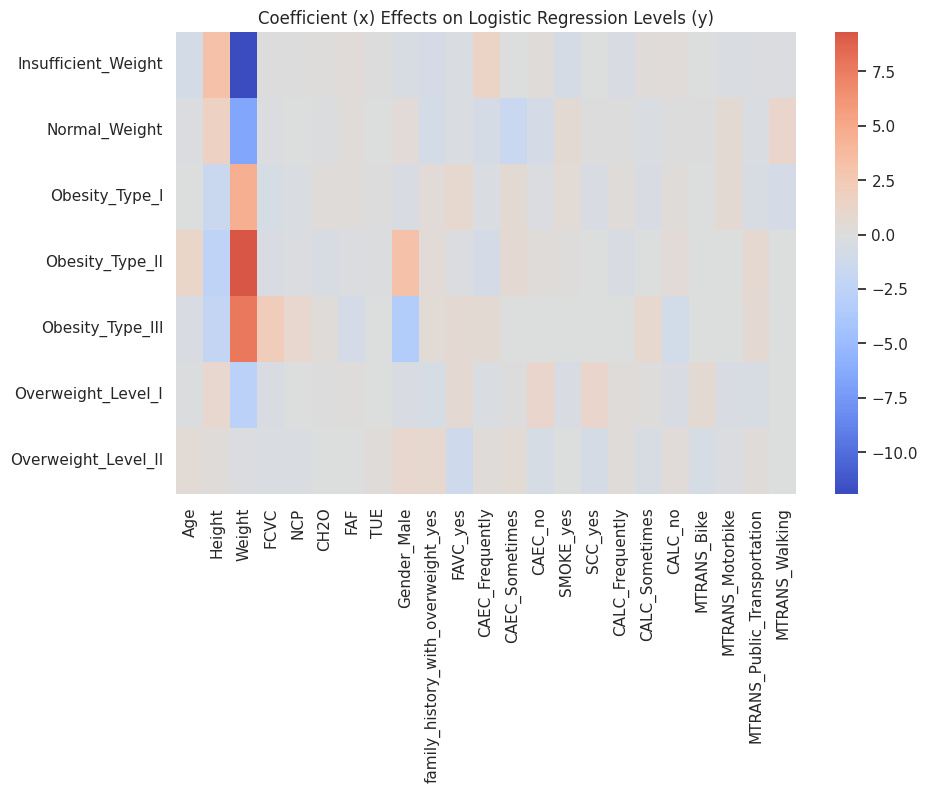

In [74]:
## visualize coefficient impact on each variable

# create dataframe
coef_lr = pd.DataFrame(lr_model.coef_,
                       columns = all_feature_names,
                       index = model.classes_)

# create plot
plt.figure(figsize = (10,6))
sns.heatmap(coef_lr, annot = False, cmap = 'coolwarm', center = 0)
plt.title('Coefficient (x) Effects on Logistic Regression Levels (y)')
plt.show()

### Random Forest

#### Preprocessing

RF does not require scaling (unlike logistic regression)

In [114]:
## data preparation per random forest formatting

# split features (x) and target (y)
X = df_clean.drop('NObeyesdad', axis = 1)
y = df_clean['NObeyesdad']

# get column types
categorical_cols = X.select_dtypes(include = ['object', 'category']).columns.tolist()
numeric_cols = X.select_dtypes(include = ['int64', 'float64']).columns.tolist()

# split 80% (train) / 20% (test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 33, stratify = y)

# one-hot encode categoricals
ohe_rf = OneHotEncoder(drop = 'first', handle_unknown = 'ignore', sparse_output = False)

X_train_cat = ohe_rf.fit_transform(X_train[categorical_cols])
X_test_cat = ohe_rf.transform(X_test[categorical_cols])

# numeric features are passed as-is (no scaling)
X_train_num = X_train[numeric_cols].to_numpy()
X_test_num = X_test[numeric_cols].to_numpy()

# combine into dense matrix
X_train_rf = np.hstack([X_train_num, X_train_cat])
X_test_rf = np.hstack([X_test_num, X_test_cat])

# build feature names for importance plotting
encoded_cat_names = ohe_rf.get_feature_names_out(categorical_cols)
rf_feature_names = numeric_cols + list(encoded_cat_names)


#### Build Base Model

In [115]:
## base model
baseline_rf = RandomForestClassifier(random_state = 33)

## train model
baseline_rf.fit(X_train_rf, y_train)

RandomForestClassifier(random_state=33)

In [116]:
## evaluate model performance
y_pred_baseline_rf = baseline_rf.predict(X_test_rf)
accuracy_basline_rf = accuracy_score(y_test, y_pred_baseline_rf)

print('Baseline Random Forest Performance:')
print(f'Accuracy = {accuracy_basline_rf:.4f}')
print('Classification Report:')
print(classification_report(y_test, y_pred_baseline_rf, target_names = class_names))

Baseline Random Forest Performance:
Accuracy = 0.9474
Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.96      0.92      0.94        53
      Normal_Weight       0.80      0.93      0.86        57
     Obesity_Type_I       0.99      0.97      0.98        70
    Obesity_Type_II       0.98      1.00      0.99        60
   Obesity_Type_III       1.00      1.00      1.00        65
 Overweight_Level_I       1.00      0.85      0.92        55
Overweight_Level_II       0.92      0.93      0.92        58

           accuracy                           0.95       418
          macro avg       0.95      0.94      0.95       418
       weighted avg       0.95      0.95      0.95       418



#### Hyperparameter Tuning

First start with a coarse randomized search

In [117]:
## tune model - randomized search (coarse search)

# search parameters
param_options = {
    'n_estimators': [200, 400, 800],
    'max_depth': [None, 10, 20, 30, 50, 80],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False],
    'criterion': ['gini', 'entropy', 'log_loss'],
    'class_weight': [None, 'balanced']
}

# perform random search
random_search = RandomizedSearchCV(
    baseline_rf,
    param_distributions = param_options,
    n_iter = 40,
    cv = 3,
    scoring = 'accuracy',
    random_state = 33,
    n_jobs = -1,
    verbose = 2
)

## fit the search
random_search.fit(X_train_rf, y_train)

print('Randomized Search Hyperparameter Tuning for Random Forest:')
print(f'Accuracy = {random_search.best_score_:.4f}')
print('Best Hyperparameters:\n', random_search.best_params_)

Fitting 3 folds for each of 40 candidates, totalling 120 fits
Randomized Search Hyperparameter Tuning for Random Forest:
Accuracy = 0.9443
Best Hyperparameters:
 {'n_estimators': 200, 'min_samples_split': 20, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': None, 'criterion': 'entropy', 'class_weight': None, 'bootstrap': True}


Use the output from the above search to perform a fine search around the identified best region.

In [118]:
## tune model - grid search (fine search around best region)

# best parameters from random search
best_params = random_search.best_params_

# search parameters
param_options = {
    'n_estimators': [best_params['n_estimators'] - 100,
                     best_params['n_estimators'],
                     best_params['n_estimators'] + 100],
    'max_depth': [best_params['max_depth'],
                  None],
    'min_samples_split': [best_params['min_samples_split'],
                          best_params['min_samples_split'] + 2],
    'min_samples_leaf': [best_params['min_samples_leaf'],
                         best_params['min_samples_leaf'] + 1],
    'max_features': [best_params['max_features']],
    'bootstrap': [best_params['bootstrap']],
    'criterion': [best_params['criterion']],
    'class_weight': [best_params['class_weight']]
}

# perform grid search
grid_search = GridSearchCV(
    baseline_rf,
    param_grid = param_options,
    scoring = 'accuracy',
    cv = 3,
    n_jobs = -1,
    verbose = 2
)

## fit the search
grid_search.fit(X_train_rf, y_train)

print('Best Hyperparameters from Grid Search:\n', grid_search.best_params_)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Hyperparameters from Grid Search:
 {'bootstrap': True, 'class_weight': None, 'criterion': 'entropy', 'max_depth': None, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 20, 'n_estimators': 200}


#### Final Model Output

In [83]:
## evaluate final tuned model

# final model
final_rf = grid_search.best_estimator_

# predict
y_pred_final = final_rf.predict(X_test_rf)
accuracy_final_rf = accuracy_score(y_test, y_pred_final)

print('Final Tuned (Best) Random Forest Model Performance:')
print(f'Accuracy = {accuracy_final_rf:.4f}')

print('\nClassification Report:')
print(classification_report(y_test, y_pred_final, target_names = class_names))

Final Tuned (Best) Random Forest Model Performance:
Accuracy = 0.9522

Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.96      0.96      0.96        53
      Normal_Weight       0.95      0.93      0.94        57
     Obesity_Type_I       0.96      0.94      0.95        70
    Obesity_Type_II       0.98      0.98      0.98        60
   Obesity_Type_III       1.00      1.00      1.00        65
 Overweight_Level_I       0.88      0.93      0.90        55
Overweight_Level_II       0.93      0.91      0.92        58

           accuracy                           0.95       418
          macro avg       0.95      0.95      0.95       418
       weighted avg       0.95      0.95      0.95       418



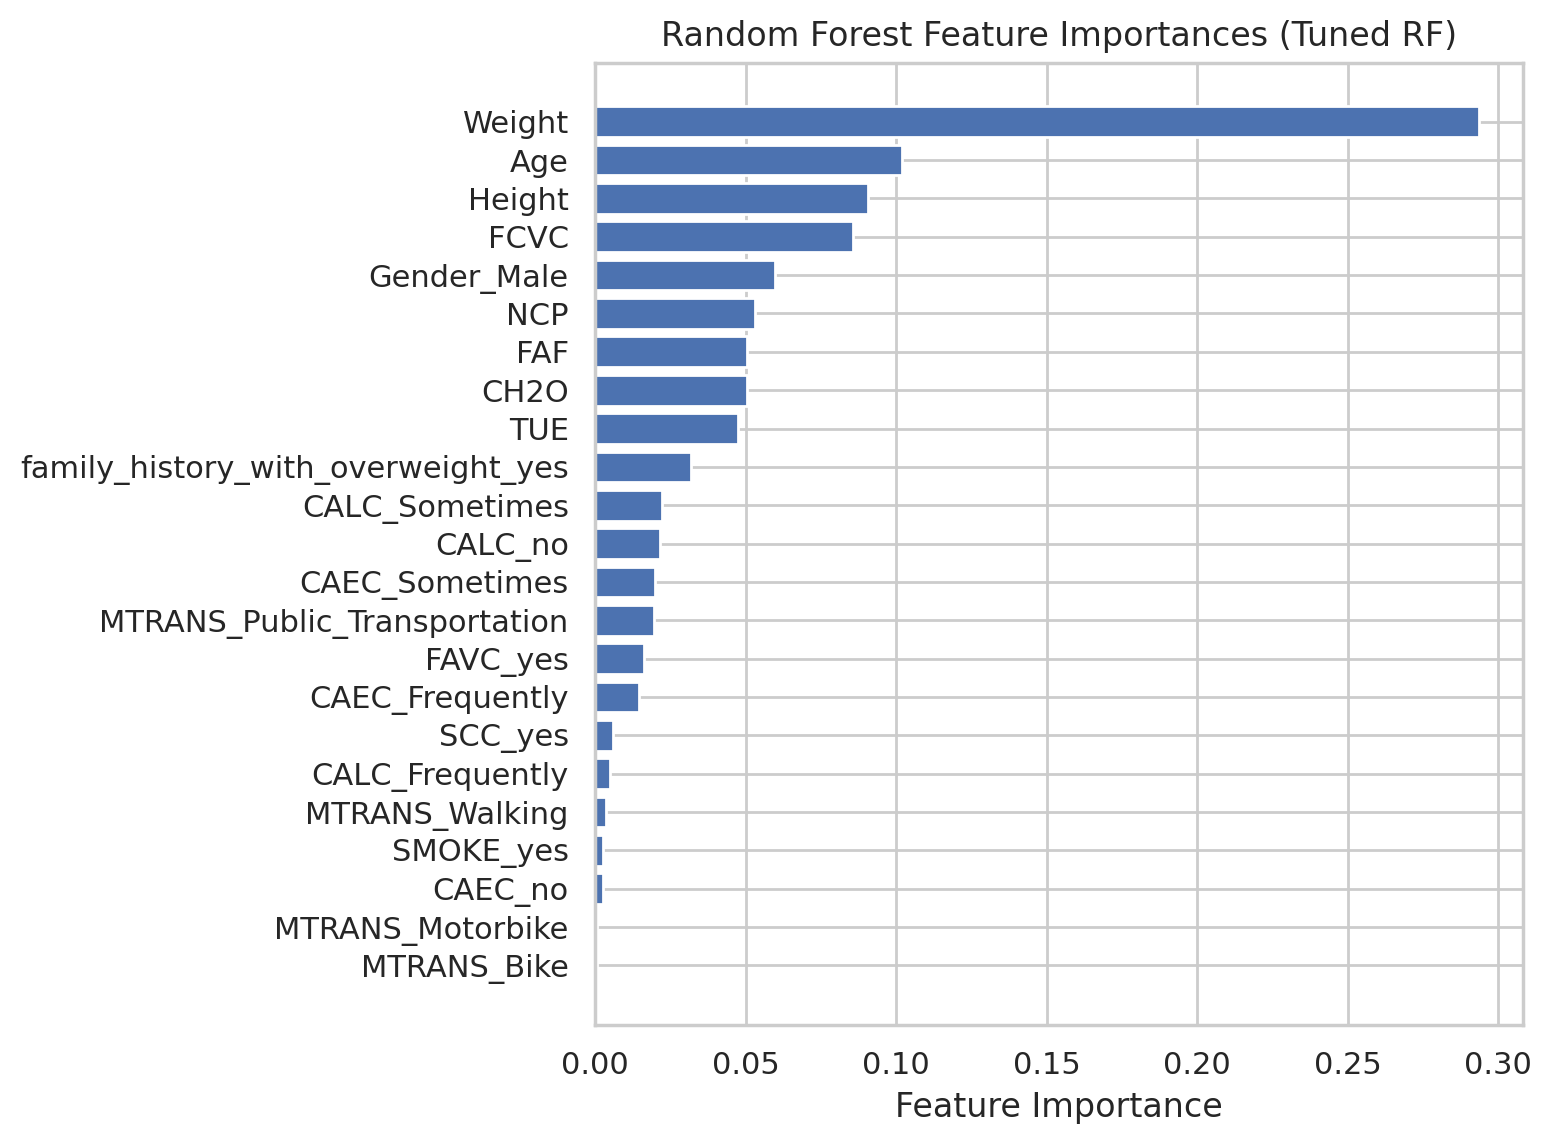

In [119]:
## create feature importance plot

# build dataframe
rf_importances = pd.DataFrame({
    'feature': rf_feature_names,
    'importance': baseline_rf.feature_importances_
}).sort_values('importance', ascending=False)

# plot
plt.figure(figsize = (8, 6))
plt.barh(rf_importances['feature'], rf_importances['importance'])
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importances (Tuned RF)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### XGBoost Model

##### Preprocessing

In [5]:
## data preparation per XGBoost formatting

# split features (x) and target (y)
X = df_clean.drop('NObeyesdad', axis = 1)
y = df_clean['NObeyesdad']

# get column types
categorical_cols = X.select_dtypes(include = ['object', 'category']).columns.tolist()
numeric_cols = X.select_dtypes(include = ['int64', 'float64']).columns.tolist()

# split 80% (train) / 20% (test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 33, stratify = y)

# one-hot encode categoricals into a sparse matrix
ohe_xgb = OneHotEncoder(
    drop = 'first',
    handle_unknown = 'ignore',
    sparse_output  =True
)

# fit OHE only on training data
X_train_cat = ohe_xgb.fit_transform(X_train[categorical_cols])
X_test_cat = ohe_xgb.transform(X_test[categorical_cols])

# numeric features: XGBoost handles scaling internally (i.e., keep raw)
X_train_num = X_train[numeric_cols].to_numpy()
X_test_num = X_test[numeric_cols].to_numpy()

# combine numeric + sparse categorical
X_train_xgb = hstack([X_train_num, X_train_cat])
X_test_xgb = hstack([X_test_num, X_test_cat])

# build feature names
encoded_cat_names = ohe_xgb.get_feature_names_out(categorical_cols)
xgb_feature_names = numeric_cols + list(encoded_cat_names)

# label encode target
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

##### Model

In [6]:
## train model
best_xgb = XGBClassifier(
    objective = 'multi:softprob',
    num_class = len(le.classes_),
    eval_metric = 'mlogloss',
    tree_method = 'hist',
    random_state = 33
)

best_xgb.fit(X_train_xgb, y_train_enc)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None, num_class=7, ...)

In [7]:
## evaluate
y_pred_enc = best_xgb.predict(X_test_xgb)
y_pred = le.inverse_transform(y_pred_enc)
y_test_labels = le.inverse_transform(y_test_enc)
accuracy_xgb = accuracy_score(y_test_labels, y_pred)

print('XGB Model Performance:')
print(f'Accuracy = {accuracy_xgb:.4f}')
print('Classification Report:')
print(classification_report(y_test_labels, y_pred))

XGB Model Performance:
Accuracy = 0.9641
Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.98      0.94      0.96        53
      Normal_Weight       0.88      0.93      0.91        57
     Obesity_Type_I       1.00      0.96      0.98        70
    Obesity_Type_II       0.98      1.00      0.99        60
   Obesity_Type_III       1.00      1.00      1.00        65
 Overweight_Level_I       0.94      0.91      0.93        55
Overweight_Level_II       0.95      1.00      0.97        58

           accuracy                           0.96       418
          macro avg       0.96      0.96      0.96       418
       weighted avg       0.96      0.96      0.96       418



##### Visualize Model

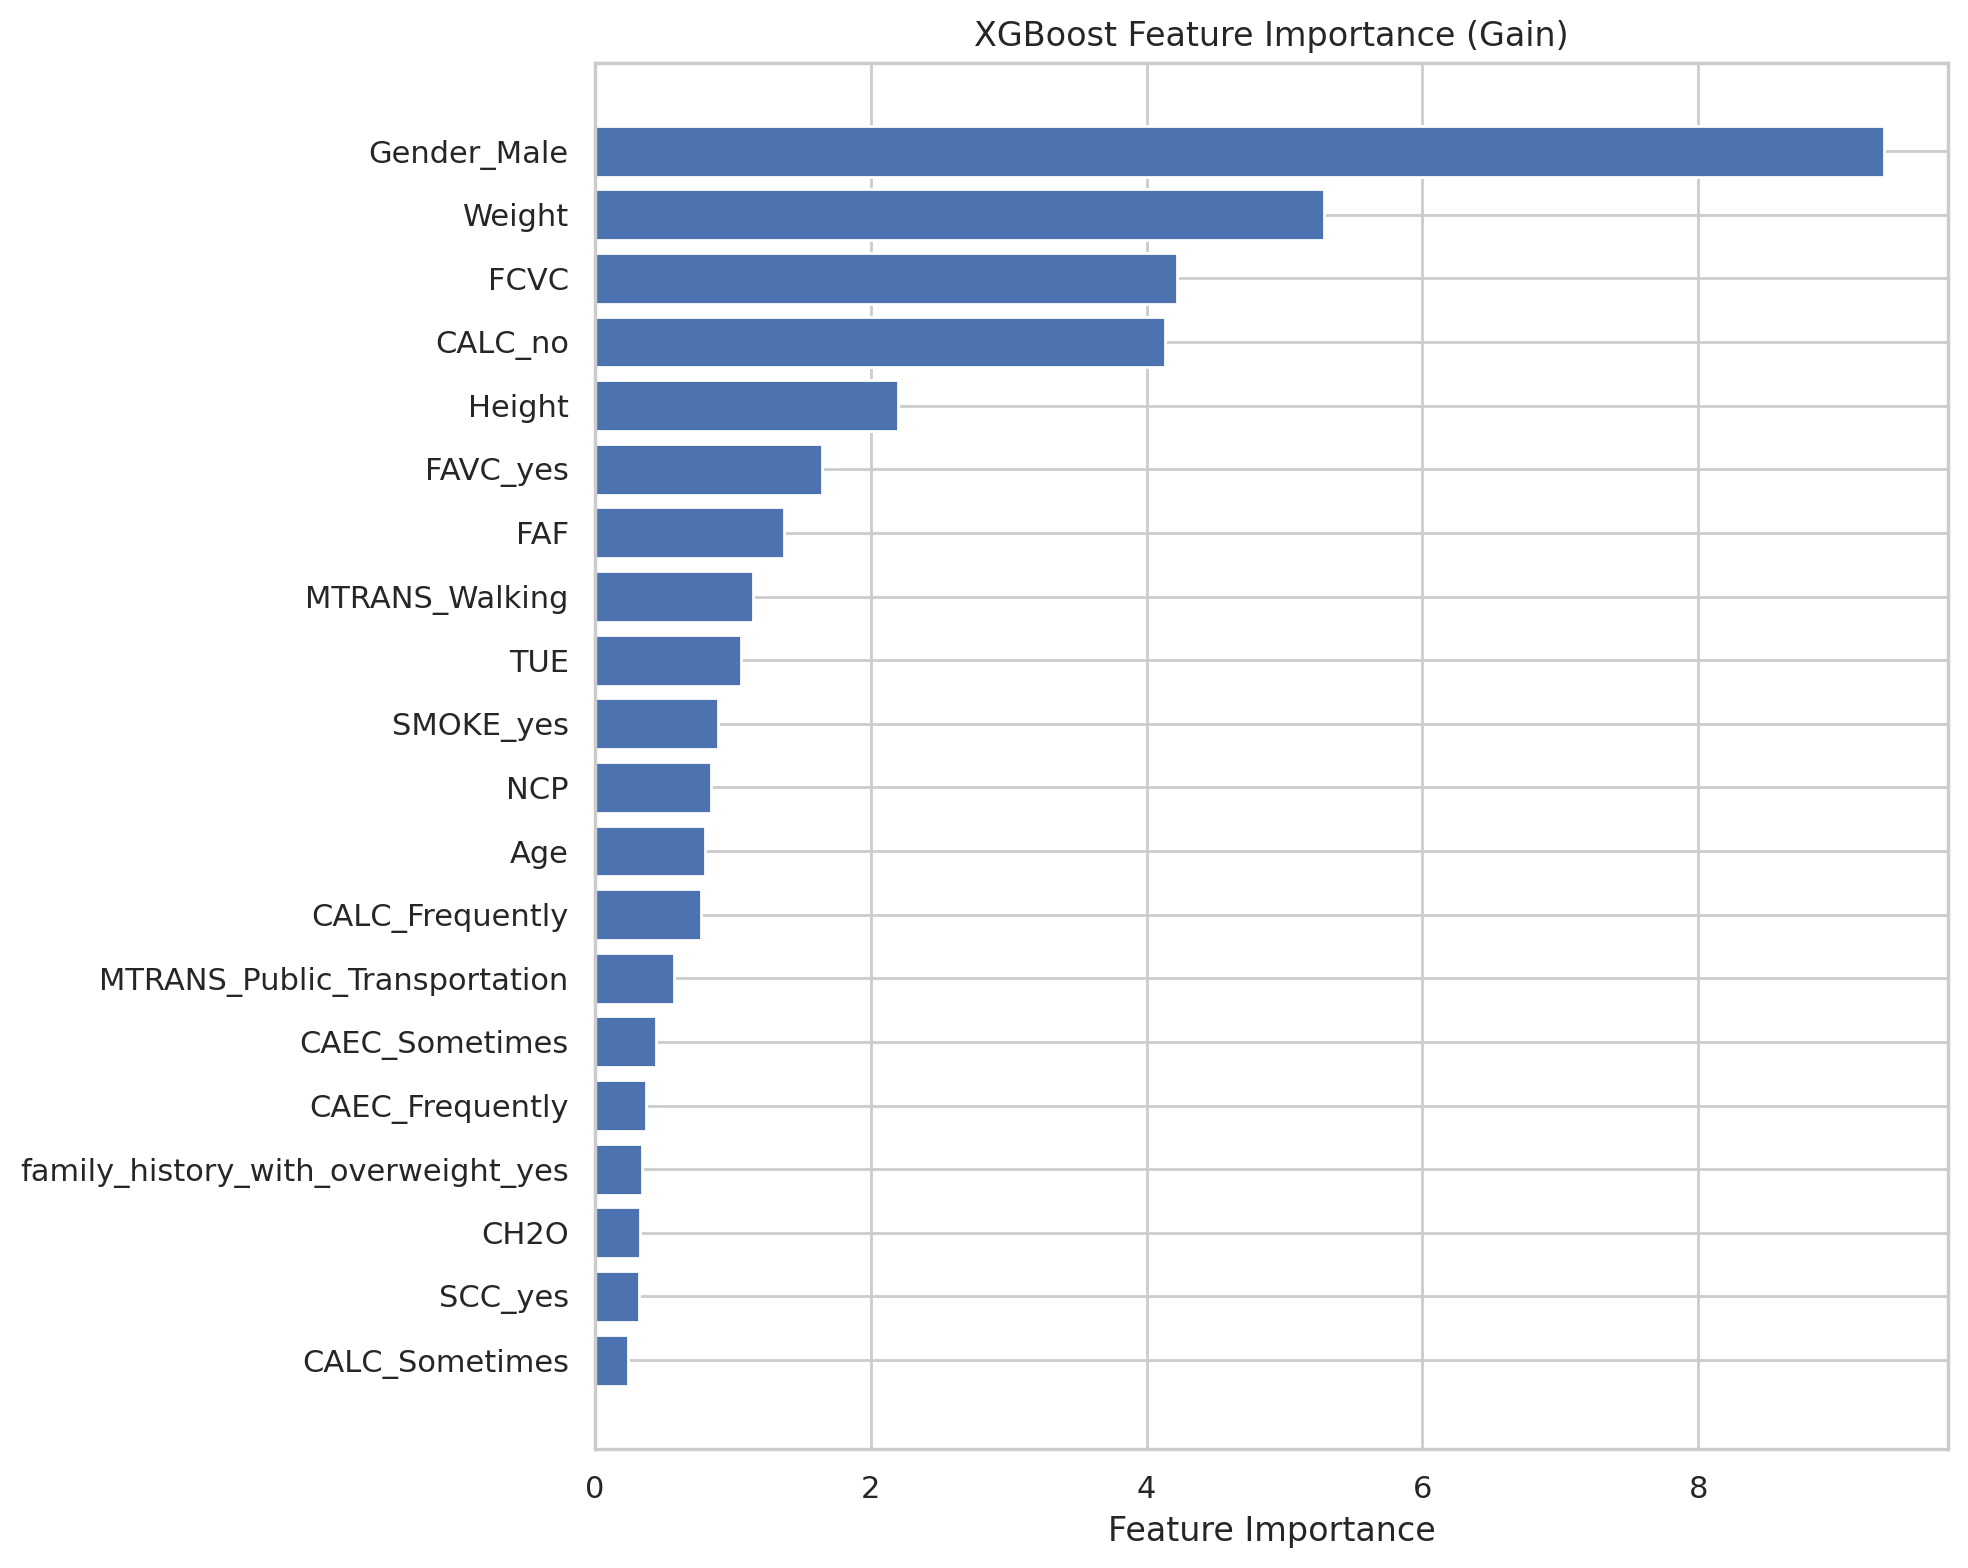

In [14]:
## plot feature importance

# extract importance scores
booster = best_xgb.get_booster()
importance_dict = booster.get_score(importance_type = 'gain')

# convert to dataframe
importance_df = pd.DataFrame({
    'feature_raw': list(importance_dict.keys()),
    'importance': list(importance_dict.values())
})

# extract numeric index from strings like "f0", "f12"
importance_df['feature_index'] = (
    importance_df['feature_raw'].str.extract(r'(\d+)').astype(int)
)

# map index to actual OHE feature name
importance_df['feature'] = importance_df['feature_index'].apply(
    lambda i: xgb_feature_names[i]
)

# sort by importance
importance_df = importance_df.sort_values('importance', ascending = False)

# create plot
plt.figure(figsize = (10, 8))
plt.barh(
    importance_df['feature'],
    importance_df['importance'])
plt.gca().invert_yaxis()
plt.title('XGBoost Feature Importance (Gain)')
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.show()

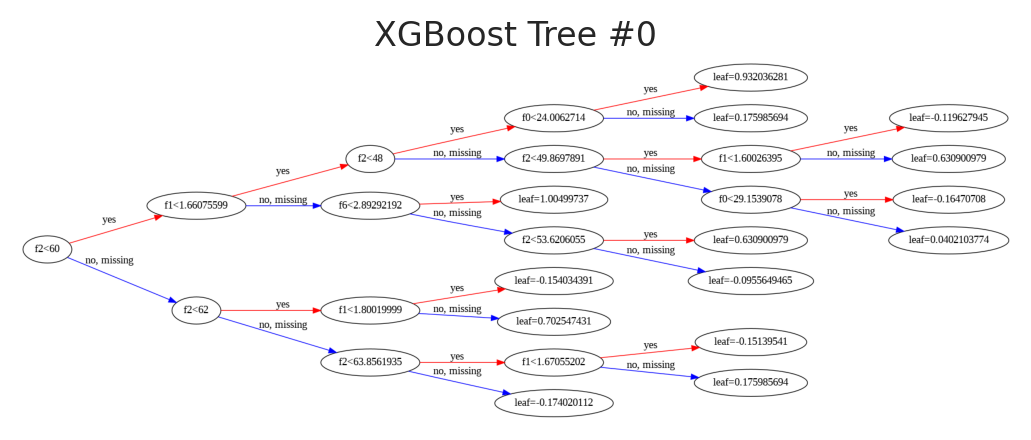

In [15]:
## tree diagram

# get feature names
best_xgb.feature_names = xgb_feature_names

# create plot
plt.rcParams['figure.dpi'] = 200
plot_tree(best_xgb, tree_idx = 0, rankdir = 'LR')
plt.title('XGBoost Tree #0')
plt.show()
